# Algoritmo Genético Simple

---
## 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


---
## 2. Parámetros del Algoritmo Genético

In [2]:
# ── Parámetros ─────────────────────────────────────────────────────────────────
Nind   = 100          # Número de individuos en la población
Lind   = 33           # Longitud del cromosoma (18 bits para X + 15 bits para Y)
Pc     = 0.9          # Probabilidad de cruzamiento
Pm     = 0.01         # Probabilidad de mutación
Maxgen = 1000         # Máximo número de generaciones
Nvar   = 2            # Número de variables

# Rangos: fila 0 = límite inferior de cada var, fila 1 = límite superior
# columna 0 → X [-3, 12.1]   |   columna 1 → Y [4.1, 5.8]
rango = np.array([[-3.0, 4.1],
                  [12.1, 5.8]])

print(f"Nind={Nind} | Lind={Lind} | Pc={Pc} | Pm={Pm} | Maxgen={Maxgen}")
print(f"Rango X: [{rango[0,0]}, {rango[1,0]}]  |  Rango Y: [{rango[0,1]}, {rango[1,1]}]")

Nind=100 | Lind=33 | Pc=0.9 | Pm=0.01 | Maxgen=1000
Rango X: [-3.0, 12.1]  |  Rango Y: [4.1, 5.8]


---
## 3. Funciones del Algoritmo Genético

In [3]:
def creapob(Nind, Lind):
    """Genera la población inicial aleatoria en binario."""
    return np.random.randint(0, 2, size=(Nind, Lind))

In [4]:
def decodifica(genotipo, rango):
    """
    Decodifica cromosomas binarios al dominio real del problema.
    Fórmula: xi = l_inf + decimal(bits) * (l_sup - l_inf) / (2^Lvar - 1)
    """
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2 ** Lvar - 1)) * fenotipo[:, i]

    return fenotipo

In [5]:
def objfun(fenotipo):
    """Evalúa la función objetivo: f(x,y) = 21.5 + x*sin(4πx) + y*sin(20πy)."""
    Nind, _ = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        objv[i, 0] = (21.5
                      + fenotipo[i, 0] * np.sin(4 * np.pi * fenotipo[i, 0])
                      + fenotipo[i, 1] * np.sin(20 * np.pi * fenotipo[i, 1]))
    return objv

In [6]:
def rankeo(objv, direccion):
    """
    Asigna aptitud por rankeo lineal.
    direccion=1 → maximizar   |   direccion=-1 → minimizar
    """
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else:
        nuevo_objv = np.sort(-1 * objv, axis=0)

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv, axis=0)
    aptitud[posori, 0] = apt.reshape(-1, 1)

    return aptitud

In [7]:
def ruleta(genotipo, fenotipo, aptitud):
    """Selección proporcional (ruleta)."""
    Nind, _ = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]

    return genotipo[idx.flatten(), :]

In [8]:
def xunpunto(nuevo_gen, Pc):
    """Cruza de un punto con probabilidad Pc."""
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind))
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(0, Lind - 1)
            aux_gen[i, :]     = np.concatenate((nuevo_gen[i, :corte],     nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :]     = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    return aux_gen

In [9]:
def muta(nuevo_gen, Pm):
    """Mutación aleatoria bit a bit con probabilidad Pm."""
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    mascara = valores <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

print("Todas las funciones definidas correctamente ✓")

Todas las funciones definidas correctamente ✓


---
## 4. Inicialización de la Población

In [10]:
# Población inicial
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv     = objfun(fenotipo)

# Arreglos para guardar historial
Mejor           = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

print(f"Población inicial creada: {genotipo.shape}")
print(f"Mejor valor inicial: {objv.max():.6f}")

Población inicial creada: (100, 33)
Mejor valor inicial: 34.056014


---
## 5. Ciclo Evolutivo (1000 generaciones)

In [11]:
generaciones = 1

while generaciones < Maxgen:

    # 1. Aptitud por rankeo
    aptitud = rankeo(objv, 1)

    # 2. Selección proporcional (ruleta)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)

    # 3. Cruza de un punto
    nuevo_gen = xunpunto(nuevo_gen, Pc)

    # 4. Mutación aleatoria
    nuevo_gen = muta(nuevo_gen, Pm)

    # 5. Decodificar y evaluar nueva población
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    # 6. Reemplazar población
    genotipo = nuevo_gen
    objv     = nuevo_objv

    # 7. Guardar mejor de esta generación
    idx = np.argmax(objv)
    Mejor[generaciones]              = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]

    generaciones += 1

print("Ciclo evolutivo terminado ✓")

Ciclo evolutivo terminado ✓


---
## 6. Resultado Final

In [12]:
mejor_gen = np.nanargmax(Mejor)
mejor_val = Mejor[mejor_gen, 0]
mejor_xy  = decodifica(Mejor_cromosoma[mejor_gen, :].reshape(1, -1), rango)

print("═" * 45)
print("   RESULTADO DEL ALGORITMO GENÉTICO")
print("═" * 45)
print(f"  Mejor generación : {mejor_gen}")
print(f"  Mejor f(x, y)    : {mejor_val:.6f}")
print(f"  x óptimo         : {mejor_xy[0, 0]:.6f}")
print(f"  y óptimo         : {mejor_xy[0, 1]:.6f}")
print("═" * 45)

═════════════════════════════════════════════
   RESULTADO DEL ALGORITMO GENÉTICO
═════════════════════════════════════════════
  Mejor generación : 184
  Mejor f(x, y)    : 37.392542
  x óptimo         : 4.098375
  y óptimo         : 12.024633
═════════════════════════════════════════════


---
## 7. Gráfica 3D de la Función Objetivo

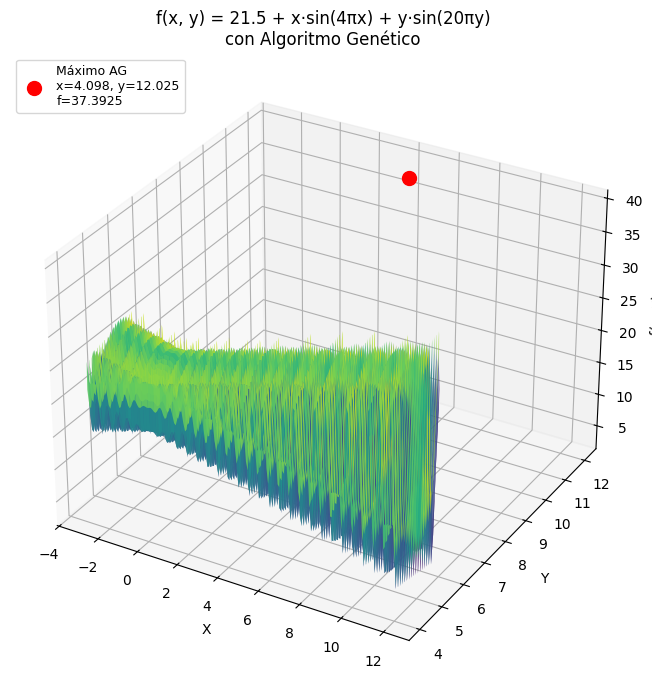

In [13]:
x_lin = np.linspace(-3, 12.1, 200)
y_lin = np.linspace(4.1, 5.8, 200)
X, Y = np.meshgrid(x_lin, y_lin)
Z = 21.5 + X * np.sin(4 * np.pi * X) + Y * np.sin(20 * np.pi * Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
ax.scatter(mejor_xy[0, 0], mejor_xy[0, 1], mejor_val,
           color='red', s=100, zorder=5,
           label=f'Máximo AG\nx={mejor_xy[0,0]:.3f}, y={mejor_xy[0,1]:.3f}\nf={mejor_val:.4f}')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('f(x, y) = 21.5 + x·sin(4πx) + y·sin(20πy)\ncon Algoritmo Genético')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Gráfica de Convergencia del AG

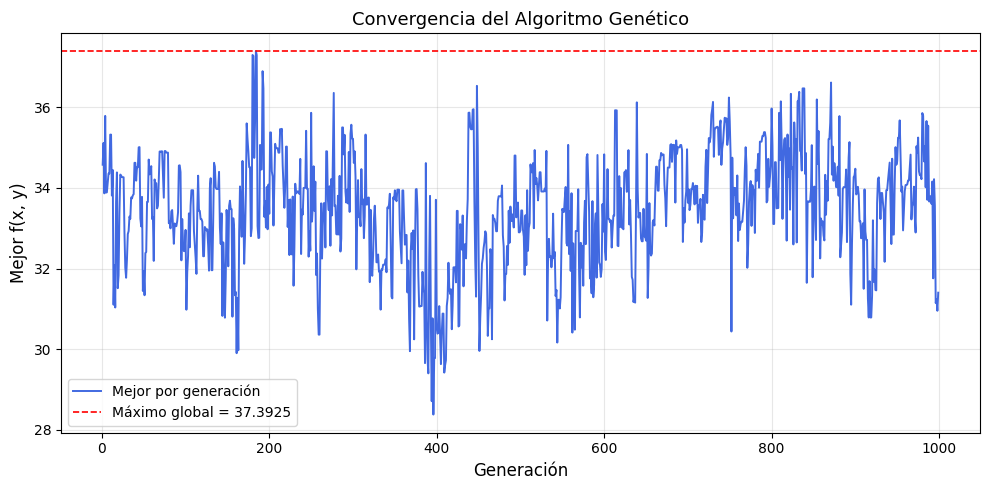

In [14]:
gens_validas = np.where(~np.isnan(Mejor[:, 0]))[0]

plt.figure(figsize=(10, 5))
plt.plot(gens_validas, Mejor[gens_validas, 0], color='royalblue', linewidth=1.4, label='Mejor por generación')
plt.axhline(y=mejor_val, color='red', linestyle='--', linewidth=1.2,
            label=f'Máximo global = {mejor_val:.4f}')
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Mejor f(x, y)', fontsize=12)
plt.title('Convergencia del Algoritmo Genético', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Comparación: AG vs Programación Estructurada (Brute Force)

In [15]:
# Máximo por búsqueda exhaustiva (malla fina)
x_bf = np.linspace(-3, 12.1, 10000)
y_bf = np.linspace(4.1, 5.8, 10000)
X_bf, Y_bf = np.meshgrid(x_bf, y_bf)
Z_bf = 21.5 + X_bf * np.sin(4 * np.pi * X_bf) + Y_bf * np.sin(20 * np.pi * Y_bf)

idx_bf  = np.unravel_index(Z_bf.argmax(), Z_bf.shape)
max_bf  = Z_bf[idx_bf]
x_bf_opt = X_bf[idx_bf]
y_bf_opt = Y_bf[idx_bf]

print("═" * 50)
print("   COMPARACIÓN DE RESULTADOS")
print("═" * 50)
print(f"  {'Método':<28} {'f(x,y)':>10}  {'x':>10}  {'y':>8}")
print("─" * 50)
print(f"  {'Algoritmo Genético':<28} {mejor_val:>10.6f}  {mejor_xy[0,0]:>10.6f}  {mejor_xy[0,1]:>8.6f}")
print(f"  {'Prog. Estructurada (brute force)':<28} {max_bf:>10.6f}  {x_bf_opt:>10.6f}  {y_bf_opt:>8.6f}")
print("─" * 50)
print(f"  Diferencia absoluta: {abs(mejor_val - max_bf):.6f}")
print(f"  Eficiencia del AG:   {(mejor_val / max_bf) * 100:.2f}%")
print("═" * 50)

══════════════════════════════════════════════════
   COMPARACIÓN DE RESULTADOS
══════════════════════════════════════════════════
  Método                           f(x,y)           x         y
──────────────────────────────────────────────────
  Algoritmo Genético            37.392542    4.098375  12.024633
  Prog. Estructurada (brute force)  38.850223   11.625813  5.725023
──────────────────────────────────────────────────
  Diferencia absoluta: 1.457682
  Eficiencia del AG:   96.25%
══════════════════════════════════════════════════
